# 재활용품 객체탐지: 전처리 → YOLO Baseline → 이미지 증강 실험 → 결과 시각화

이 노트북은 업로드된 `data_0.1pct.zip`을 기준으로 다음 작업을 한 파일 안에서 재현하도록 구성했습니다.

1. 원본 JSON 라벨을 점검하고 Ultralytics YOLO detection 형식으로 변환
2. 데이터 누수·깨진 라벨·클래스 불균형·bbox 분포 점검
3. YOLO26n 기반 baseline 학습 코드
4. OpenCV 오프라인 증강과 YOLO 내장 증강을 각각/조합하여 비교
5. 모든 실험의 Precision / Recall / mAP50 / mAP50-95 / 학습시간을 표로 통합
6. 성능 비교 그래프와 best run의 PR curve / confusion matrix / 학습 curve 확인
7. 희소 클래스 support를 고려한 해석 및 상위 조합 multi-seed 재검증

## 업로드본에서 사전 확인한 핵심 사실

- 이미지: **652장** = Training 536 + Validation 116
- 실제 객체 bbox: **727개** = Training 602 + Validation 125
- 원본 도형: **BOX 703개 + POLYGON 24개**
- 대분류: **12개**
- 세부분류명: **74개**
- 실제 탐지 클래스(`대분류/세부분류` 조합): **86개**
- `POLYGON` 24개는 detection용 최소 외접 사각형 bbox로 변환 가능
- 원본 이미지 652장은 모두 정상 디코딩됨
- JSON `RESOLUTION`과 실제 이미지 크기 불일치: **0건**
- 동일 이미지 바이트 중복 / train-val exact duplicate: **0건**
- bbox 변환 후 유효하지 않은 bbox: **0건**
- Validation에 없는 클래스: `의류/기타`, `캔류/기타`, `형광등/기타`
- 86개 클래스 중 **48개 클래스가 전체 객체 수 5개 이하** → 이 0.1% 샘플의 클래스별 AP는 변동성이 매우 큼
- 모든 이미지가 `주간`; 실외 587장 / 실내 65장

> 따라서 이 0.1% 데이터는 **증강 파이프라인 반복 테스트 및 baseline sanity check**에는 좋지만,
> 최종 모델의 절대 성능을 판단하기에는 너무 작습니다. 최종 결론은 더 큰 학습 데이터와 별도 Test set에서 확인하세요.

### 클래스 정책

폴더 경로의 세부분류만 사용하지 않고 **JSON 내부 각 `Bounding` 객체의 `CLASS` + `DETAILS`**를 사용합니다.
이유는 한 이미지에 폴더명과 다른 객체가 함께 라벨링된 사례가 있기 때문입니다.

또한 원본 JSON의 대분류 표기 중 `나무류/비닐류/스티로폼류/유리병류/페트병류`는
폴더명과 맞도록 `나무/비닐/스티로폼/유리병/페트병`으로 정규화합니다.

예: `고철류/프라이팬`, `도기류/주전자`, `고철류/주전자`는 서로 다른 클래스로 유지합니다.

## 0. 환경 설치

프로젝트에서 `uv`를 사용한다면 터미널에서 아래 패키지를 프로젝트 환경에 추가하는 것을 권장합니다.

```bash
uv add ultralytics opencv-python pandas numpy matplotlib pyyaml tqdm
```

Jupyter 커널은 프로젝트의 `.venv`를 선택하세요.

작성 시점의 Ultralytics 공식 문서는 `yolo26n.pt`를 nano baseline 예시로 사용합니다.
설치된 Ultralytics 버전이 너무 오래되어 YOLO26을 지원하지 않는다면 패키지를 업데이트하거나,
`MODEL_NAME = "yolo11n.pt"`처럼 설치 버전에 맞는 nano 모델로 바꿔도 나머지 실험 구조는 동일합니다.

공식 문서:
- Detect dataset format: https://docs.ultralytics.com/datasets/detect/
- Training: https://docs.ultralytics.com/modes/train/
- Data augmentation: https://docs.ultralytics.com/guides/yolo-data-augmentation/

In [1]:
from __future__ import annotations

import os
import sys
import json
import math
import time
import random
import shutil
import hashlib
import platform
import zipfile
from pathlib import Path
from collections import Counter, defaultdict

import cv2
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from IPython.display import display, Image as IPImage

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

def set_korean_font():
    candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR"]
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False

set_korean_font()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("OpenCV:", cv2.__version__)

Python: 3.13.5
Platform: Linux-6.18.35-x86_64-with-glibc2.41
OpenCV: 4.13.0


## 1. 경로와 실험 설정

- `ZIP_PATH`: 원본 zip 위치
- `WORK_DIR`: 전처리/실험 결과 저장 폴더
- `RUN_TRAINING`: 실제 YOLO 학습을 실행할지 여부
- `FAST_MODE`: 빠른 파이프라인 점검용. `False`면 전체 실험을 수행하도록 구성
- Validation은 **절대 증강하지 않습니다.**

In [2]:
# ---------- Path ----------
ZIP_CANDIDATES = [
    Path("data_0.1pct.zip"),
    Path("/mnt/data/data_0.1pct.zip"),
]

ZIP_PATH = next((p for p in ZIP_CANDIDATES if p.exists()), None)
if ZIP_PATH is None:
    raise FileNotFoundError(
        "data_0.1pct.zip을 찾지 못했습니다. ZIP_CANDIDATES 또는 ZIP_PATH를 실제 위치에 맞게 수정하세요."
    )

WORK_DIR = Path("yolo_recycling_experiment").resolve()
DATASET_DIR = WORK_DIR / "yolo_dataset"
RUNS_DIR = WORK_DIR / "runs"
REPORT_DIR = WORK_DIR / "reports"

for p in [WORK_DIR, DATASET_DIR, RUNS_DIR, REPORT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# ---------- YOLO ----------
MODEL_NAME = "yolo26n.pt"
IMGSZ = 640
BATCH = 8
WORKERS = 0        # Windows/Jupyter에서 멀티프로세싱 문제를 피하기 위한 안전한 값
FAST_MODE = False
RUN_TRAINING = False

EPOCHS = 12 if FAST_MODE else 60
PATIENCE = EPOCHS  # 실험 간 epoch 수를 최대한 동일하게 유지

# OpenCV offline augmentation
CV2_AUG_COPIES = 1

print("ZIP_PATH   :", ZIP_PATH.resolve())
print("WORK_DIR   :", WORK_DIR)
print("MODEL_NAME :", MODEL_NAME)
print("EPOCHS     :", EPOCHS)
print("RUN_TRAINING:", RUN_TRAINING)

ZIP_PATH   : /mnt/data/data_0.1pct.zip
WORK_DIR   : /mnt/data/notebook_execution_check/yolo_recycling_experiment
MODEL_NAME : yolo26n.pt
EPOCHS     : 60
RUN_TRAINING: False


## 2. 원본 ZIP 구조와 manifest 확인

In [3]:
with zipfile.ZipFile(ZIP_PATH) as zf:
    members = zf.namelist()
    image_members = [n for n in members if n.lower().endswith((".jpg", ".jpeg", ".png", ".webp", ".bmp"))]
    json_members = [n for n in members if n.lower().endswith(".json")]
    manifest_name = next(n for n in members if n.endswith("sample_manifest.csv"))
    manifest = pd.read_csv(zf.open(manifest_name))

print("ZIP entries:", len(members))
print("Images     :", len(image_members))
print("JSON labels:", len(json_members))
display(manifest.head())
display(manifest["split"].value_counts().rename("images").to_frame())

ZIP entries: 3002
Images     : 652
JSON labels: 652


,split,major_category,detail_category,source_image,source_label,output_image,output_label
0,Training,고철류,고철,Training\images\고철류\고철\12_X002_C193_1125\12_X0...,Training\labels\고철류\고철\12_X002_C193_1125\12_X0...,Training\images\고철류\고철\12_X002_C193_1125\12_X0...,Training\labels\고철류\고철\12_X002_C193_1125\12_X0...
1,Training,고철류,고철,Training\images\고철류\고철\12_X003_C014_1102\12_X0...,Training\labels\고철류\고철\12_X003_C014_1102\12_X0...,Training\images\고철류\고철\12_X003_C014_1102\12_X0...,Training\labels\고철류\고철\12_X003_C014_1102\12_X0...
2,Training,고철류,고철,Training\images\고철류\고철\12_X004_C163_1130\12_X0...,Training\labels\고철류\고철\12_X004_C163_1130\12_X0...,Training\images\고철류\고철\12_X004_C163_1130\12_X0...,Training\labels\고철류\고철\12_X004_C163_1130\12_X0...
3,Training,고철류,고철,Training\images\고철류\고철\12_X005_C058_1204\12_X0...,Training\labels\고철류\고철\12_X005_C058_1204\12_X0...,Training\images\고철류\고철\12_X005_C058_1204\12_X0...,Training\labels\고철류\고철\12_X005_C058_1204\12_X0...
4,Training,고철류,고철,Training\images\고철류\고철\12_X005_C187_1130\12_X0...,Training\labels\고철류\고철\12_X005_C187_1130\12_X0...,Training\images\고철류\고철\12_X005_C187_1130\12_X0...,Training\labels\고철류\고철\12_X005_C187_1130\12_X0...


,images
split,
Training,536
Validation,116


## 3. 라벨 파서와 전처리 규칙

### 중요한 규칙

1. `BOX` 라벨: `x1, y1, x2, y2`를 그대로 사용
2. `POLYGON` 라벨: 모든 polygon point의 `min/max`로 detection bbox 생성
3. bbox는 실제 이미지 범위로 clip
4. YOLO 라벨은 `class_id x_center y_center width height`이며 모두 0~1 정규화
5. class id는 `canonical_major/DETAILS` 조합으로 생성
6. 이미지 파일명은 현재 샘플에서 중복이 없으므로 split 폴더 아래 flat 구조로 저장

In [4]:
CANON_MAJOR = {
    "나무류": "나무",
    "비닐류": "비닐",
    "스티로폼류": "스티로폼",
    "유리병류": "유리병",
    "페트병류": "페트병",
}

def canonical_major(name: str) -> str:
    name = str(name).strip()
    return CANON_MAJOR.get(name, name)

def parse_resolution(value: str) -> tuple[int | None, int | None]:
    value = str(value).replace(" ", "")
    for sep in ("*", "x", "X"):
        if sep in value:
            a, b = value.split(sep, 1)
            if a.isdigit() and b.isdigit():
                return int(a), int(b)
    return None, None

def polygon_points_to_xyxy(polygon_points) -> tuple[float, float, float, float]:
    pts = []
    for item in polygon_points or []:
        if not item:
            continue
        raw = next(iter(item.values()))
        x, y = str(raw).split(",")
        pts.append((float(x), float(y)))
    if not pts:
        raise ValueError("PolygonPoint가 비어 있습니다.")
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    return min(xs), min(ys), max(xs), max(ys)

def bounding_to_xyxy(b: dict) -> tuple[float, float, float, float, str]:
    if all(k in b for k in ("x1", "y1", "x2", "y2")):
        return float(b["x1"]), float(b["y1"]), float(b["x2"]), float(b["y2"]), "BOX"
    if b.get("PolygonPoint"):
        x1, y1, x2, y2 = polygon_points_to_xyxy(b["PolygonPoint"])
        return x1, y1, x2, y2, "POLYGON->BOX"
    raise ValueError("BOX 좌표와 PolygonPoint가 모두 없습니다.")

def clip_xyxy(x1, y1, x2, y2, width, height):
    x1 = float(np.clip(x1, 0, width))
    x2 = float(np.clip(x2, 0, width))
    y1 = float(np.clip(y1, 0, height))
    y2 = float(np.clip(y2, 0, height))
    return x1, y1, x2, y2

def xyxy_to_yolo(x1, y1, x2, y2, width, height):
    xc = ((x1 + x2) / 2.0) / width
    yc = ((y1 + y2) / 2.0) / height
    bw = (x2 - x1) / width
    bh = (y2 - y1) / height
    return xc, yc, bw, bh

def json_to_image_member(json_member: str) -> str:
    stem = json_member.rsplit(".", 1)[0]
    return stem.replace("/labels/", "/images/") + ".jpg"

## 4. 실제 Bounding 객체에서 클래스 목록 만들기

폴더 이름이 아니라 각 객체의 JSON 라벨을 기준으로 class mapping을 만듭니다.

In [5]:
object_class_names = set()
source_geometry_counter = Counter()

with zipfile.ZipFile(ZIP_PATH) as zf:
    for json_member in json_members:
        payload = json.load(zf.open(json_member))
        for b in payload.get("Bounding") or []:
            major = canonical_major(b.get("CLASS", "UNKNOWN"))
            detail = str(b.get("DETAILS", "UNKNOWN")).strip()
            object_class_names.add(f"{major}/{detail}")
            if all(k in b for k in ("x1", "y1", "x2", "y2")):
                source_geometry_counter["BOX"] += 1
            elif b.get("PolygonPoint"):
                source_geometry_counter["POLYGON"] += 1
            else:
                source_geometry_counter["UNKNOWN"] += 1

CLASS_NAMES = sorted(object_class_names)
CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}
ID_TO_CLASS = {i: name for name, i in CLASS_TO_ID.items()}

print("Number of detection classes:", len(CLASS_NAMES))
print("Source geometry:", dict(source_geometry_counter))
display(pd.DataFrame({"class_id": range(len(CLASS_NAMES)), "class_name": CLASS_NAMES}).head(30))

Number of detection classes: 86
Source geometry: {'BOX': 703, 'POLYGON': 24}


,class_id,class_name
0,0,고철류/고철
1,1,고철류/골프채
2,2,고철류/기타
3,3,고철류/비철금속
4,4,고철류/전기프라이팬
5,5,고철류/주전자
6,6,고철류/철옷걸이
7,7,고철류/프라이팬
8,8,나무/기타
9,9,나무/나무행거


## 5. JSON → Ultralytics YOLO detection dataset 변환

생성 구조:

```text
yolo_dataset/
├─ images/
│  ├─ train/
│  └─ val/
├─ labels/
│  ├─ train/
│  └─ val/
├─ data.yaml
├─ class_mapping.csv
├─ image_report.csv
└─ object_report.csv
```

`object_report.csv`에는 원본 도형 종류, 원본 경로 클래스, 실제 Bounding 클래스, bbox 면적비 등을 남겨
전처리 과정이 추적 가능하도록 합니다.

In [6]:
def preprocess_to_yolo(overwrite: bool = False):
    if overwrite and DATASET_DIR.exists():
        shutil.rmtree(DATASET_DIR)

    for split in ("train", "val"):
        (DATASET_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
        (DATASET_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

    image_rows = []
    object_rows = []
    errors = []
    seen_basenames = set()

    with zipfile.ZipFile(ZIP_PATH) as zf:
        for json_member in sorted(json_members):
            parts = Path(json_member).parts
            # data_0.1pct / Training|Validation / labels / major / detail / scene / file.json
            source_split = parts[1]
            split = "train" if source_split.lower().startswith("train") else "val"
            path_major = parts[3]
            path_detail = parts[4]

            payload = json.load(zf.open(json_member))
            image_member = json_to_image_member(json_member)

            if image_member not in zf.namelist():
                errors.append({"json": json_member, "error": f"missing image: {image_member}"})
                continue

            image_bytes = zf.read(image_member)
            image_hash = hashlib.sha1(image_bytes).hexdigest()
            image = cv2.imdecode(np.frombuffer(image_bytes, np.uint8), cv2.IMREAD_COLOR)
            if image is None:
                errors.append({"json": json_member, "error": "cv2.imdecode failed"})
                continue

            height, width = image.shape[:2]
            meta_w, meta_h = parse_resolution(payload.get("RESOLUTION", ""))

            basename = Path(image_member).name
            if basename in seen_basenames:
                raise RuntimeError(f"Flat 구조에서 파일명 충돌: {basename}")
            seen_basenames.add(basename)

            out_img = DATASET_DIR / "images" / split / basename
            out_lbl = DATASET_DIR / "labels" / split / f"{Path(basename).stem}.txt"
            out_img.write_bytes(image_bytes)

            yolo_lines = []
            valid_count = 0
            bounds = payload.get("Bounding") or []

            for obj_idx, b in enumerate(bounds):
                try:
                    x1, y1, x2, y2, source_geometry = bounding_to_xyxy(b)
                    raw_xyxy = (x1, y1, x2, y2)
                    x1, y1, x2, y2 = clip_xyxy(x1, y1, x2, y2, width, height)

                    if x2 <= x1 or y2 <= y1:
                        raise ValueError(f"invalid box after clip: {(x1, y1, x2, y2)}")

                    major = canonical_major(b.get("CLASS", "UNKNOWN"))
                    detail = str(b.get("DETAILS", "UNKNOWN")).strip()
                    class_name = f"{major}/{detail}"
                    class_id = CLASS_TO_ID[class_name]

                    xc, yc, bw, bh = xyxy_to_yolo(x1, y1, x2, y2, width, height)
                    values = np.array([xc, yc, bw, bh], dtype=float)
                    if not np.all((values >= 0) & (values <= 1)):
                        raise ValueError(f"normalized bbox out of range: {values}")

                    yolo_lines.append(
                        f"{class_id} {xc:.8f} {yc:.8f} {bw:.8f} {bh:.8f}"
                    )
                    valid_count += 1

                    object_rows.append({
                        "split": split,
                        "image_name": basename,
                        "json_member": json_member,
                        "object_index": obj_idx,
                        "path_major": path_major,
                        "path_detail": path_detail,
                        "box_major_raw": b.get("CLASS"),
                        "box_major_canonical": major,
                        "box_detail": detail,
                        "class_name": class_name,
                        "class_id": class_id,
                        "source_geometry": source_geometry,
                        "raw_x1": raw_xyxy[0],
                        "raw_y1": raw_xyxy[1],
                        "raw_x2": raw_xyxy[2],
                        "raw_y2": raw_xyxy[3],
                        "x1": x1,
                        "y1": y1,
                        "x2": x2,
                        "y2": y2,
                        "bbox_area_ratio": ((x2 - x1) * (y2 - y1)) / (width * height),
                        "bbox_aspect_ratio": (x2 - x1) / (y2 - y1),
                    })
                except Exception as e:
                    errors.append({
                        "json": json_member,
                        "object_index": obj_idx,
                        "error": repr(e),
                    })

            out_lbl.write_text("\n".join(yolo_lines), encoding="utf-8")

            image_rows.append({
                "split": split,
                "image_name": basename,
                "image_member": image_member,
                "json_member": json_member,
                "width": width,
                "height": height,
                "meta_width": meta_w,
                "meta_height": meta_h,
                "resolution_match": (width == meta_w and height == meta_h),
                "objects": valid_count,
                "declared_bounding_count": int(payload.get("BoundingCount", len(bounds))),
                "day_night": payload.get("DAY/NIGHT"),
                "place": payload.get("PLACE"),
                "sha1": image_hash,
            })

    image_df = pd.DataFrame(image_rows)
    object_df = pd.DataFrame(object_rows)
    error_df = pd.DataFrame(errors)

    mapping_df = pd.DataFrame({
        "class_id": range(len(CLASS_NAMES)),
        "class_name": CLASS_NAMES,
    })

    image_df.to_csv(DATASET_DIR / "image_report.csv", index=False, encoding="utf-8-sig")
    object_df.to_csv(DATASET_DIR / "object_report.csv", index=False, encoding="utf-8-sig")
    mapping_df.to_csv(DATASET_DIR / "class_mapping.csv", index=False, encoding="utf-8-sig")
    error_df.to_csv(DATASET_DIR / "preprocess_errors.csv", index=False, encoding="utf-8-sig")

    data_yaml = {
        "path": str(DATASET_DIR.resolve()),
        "train": "images/train",
        "val": "images/val",
        "names": {i: name for i, name in enumerate(CLASS_NAMES)},
    }
    with open(DATASET_DIR / "data.yaml", "w", encoding="utf-8") as f:
        yaml.safe_dump(data_yaml, f, allow_unicode=True, sort_keys=False)

    return image_df, object_df, error_df

image_df, object_df, error_df = preprocess_to_yolo(overwrite=False)

print("YOLO dataset:", DATASET_DIR)
print("images:", len(image_df), "objects:", len(object_df), "errors:", len(error_df))
display(image_df.groupby("split").agg(images=("image_name", "count"), objects=("objects", "sum")))
if len(error_df):
    display(error_df.head(20))

YOLO dataset: /mnt/data/notebook_execution_check/yolo_recycling_experiment/yolo_dataset
images: 652 objects: 727 errors: 0


,images,objects
split,,
train,536,602
val,116,125


## 6. 전처리 QA

여기서는 다음을 자동 검증합니다.

- train / val 이미지 수
- 이미지와 라벨 파일 1:1 대응
- JSON 선언 bbox 수와 실제 변환 bbox 수
- 이미지 실제 해상도와 JSON `RESOLUTION`
- exact duplicate 이미지 및 train-val 누수
- bbox 범위 / 크기
- 클래스별 train/val support

In [7]:
def yolo_label_files(split):
    return list((DATASET_DIR / "labels" / split).glob("*.txt"))

def yolo_image_files(split):
    return list((DATASET_DIR / "images" / split).glob("*.*"))

qa_summary = {
    "train_images": len(yolo_image_files("train")),
    "val_images": len(yolo_image_files("val")),
    "train_labels": len(yolo_label_files("train")),
    "val_labels": len(yolo_label_files("val")),
    "objects_total": len(object_df),
    "box_source_count": int((object_df["source_geometry"] == "BOX").sum()),
    "polygon_to_box_count": int((object_df["source_geometry"] == "POLYGON->BOX").sum()),
    "resolution_mismatch": int((~image_df["resolution_match"]).sum()),
    "exact_duplicate_rows": int(image_df.duplicated("sha1", keep=False).sum()),
    "preprocess_error_rows": len(error_df),
}

display(pd.Series(qa_summary, name="value").to_frame())

# train-val exact duplicate 검사
cross_split_dups = (
    image_df.groupby("sha1")["split"]
    .nunique()
    .loc[lambda s: s > 1]
)
print("Cross-split exact duplicate groups:", len(cross_split_dups))

# bbox validity
bbox_valid = (
    (object_df["x2"] > object_df["x1"])
    & (object_df["y2"] > object_df["y1"])
    & (object_df["bbox_area_ratio"] > 0)
    & (object_df["bbox_area_ratio"] <= 1)
)
print("Invalid bbox rows:", int((~bbox_valid).sum()))

# 클래스 support
support = (
    object_df.groupby(["class_name", "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["train", "val"], fill_value=0)
)
support["total"] = support["train"] + support["val"]
support["val_missing"] = support["val"].eq(0)
support["rare_total_le_5"] = support["total"].le(5)
support = support.sort_values(["total", "class_name"], ascending=[True, True])

print("Detection classes:", len(support))
print("Classes missing from validation:", int(support["val_missing"].sum()))
print("Classes with <=5 total objects:", int(support["rare_total_le_5"].sum()))
display(support.head(40))

,value
train_images,536
val_images,116
train_labels,536
val_labels,116
objects_total,727
box_source_count,703
polygon_to_box_count,24
resolution_mismatch,0
exact_duplicate_rows,0
preprocess_error_rows,0


Cross-split exact duplicate groups: 0
Invalid bbox rows: 0
Detection classes: 86
Classes missing from validation: 3
Classes with <=5 total objects: 48


split,train,val,total,val_missing,rare_total_le_5
class_name,,,,,
의류/기타,1,0,1,True,True
캔류/기타,1,0,1,True,True
고철류/기타,1,1,2,False,True
고철류/전기프라이팬,1,1,2,False,True
고철류/주전자,1,1,2,False,True
나무/나무행거,1,1,2,False,True
도기류/기타,1,1,2,False,True
도기류/병,1,1,2,False,True
도기류/장식품,1,1,2,False,True


### 데이터 해석 시 주의

이 샘플은 클래스 수(86)에 비해 이미지/객체 수가 작습니다.
따라서 augmentation 조합끼리 **같은 split / 같은 seed / 같은 model / 같은 epoch**로 비교해야 합니다.

또한 여러 augmentation을 검증셋 성능으로 고른 뒤 최종 성능을 발표하려면,
검증셋과 별도의 **Test set**이 필요합니다.

In [8]:
# split / 장소 / 주야간 요약
display(
    image_df.groupby(["split", "place"], dropna=False)
    .size()
    .rename("images")
    .reset_index()
)

display(
    image_df["day_night"]
    .value_counts(dropna=False)
    .rename("images")
    .to_frame()
)

,split,place,images
0,train,실내,54
1,train,실외,482
2,val,실내,11
3,val,실외,105


,images
day_night,
주간,652


## 7. 데이터 분포 시각화

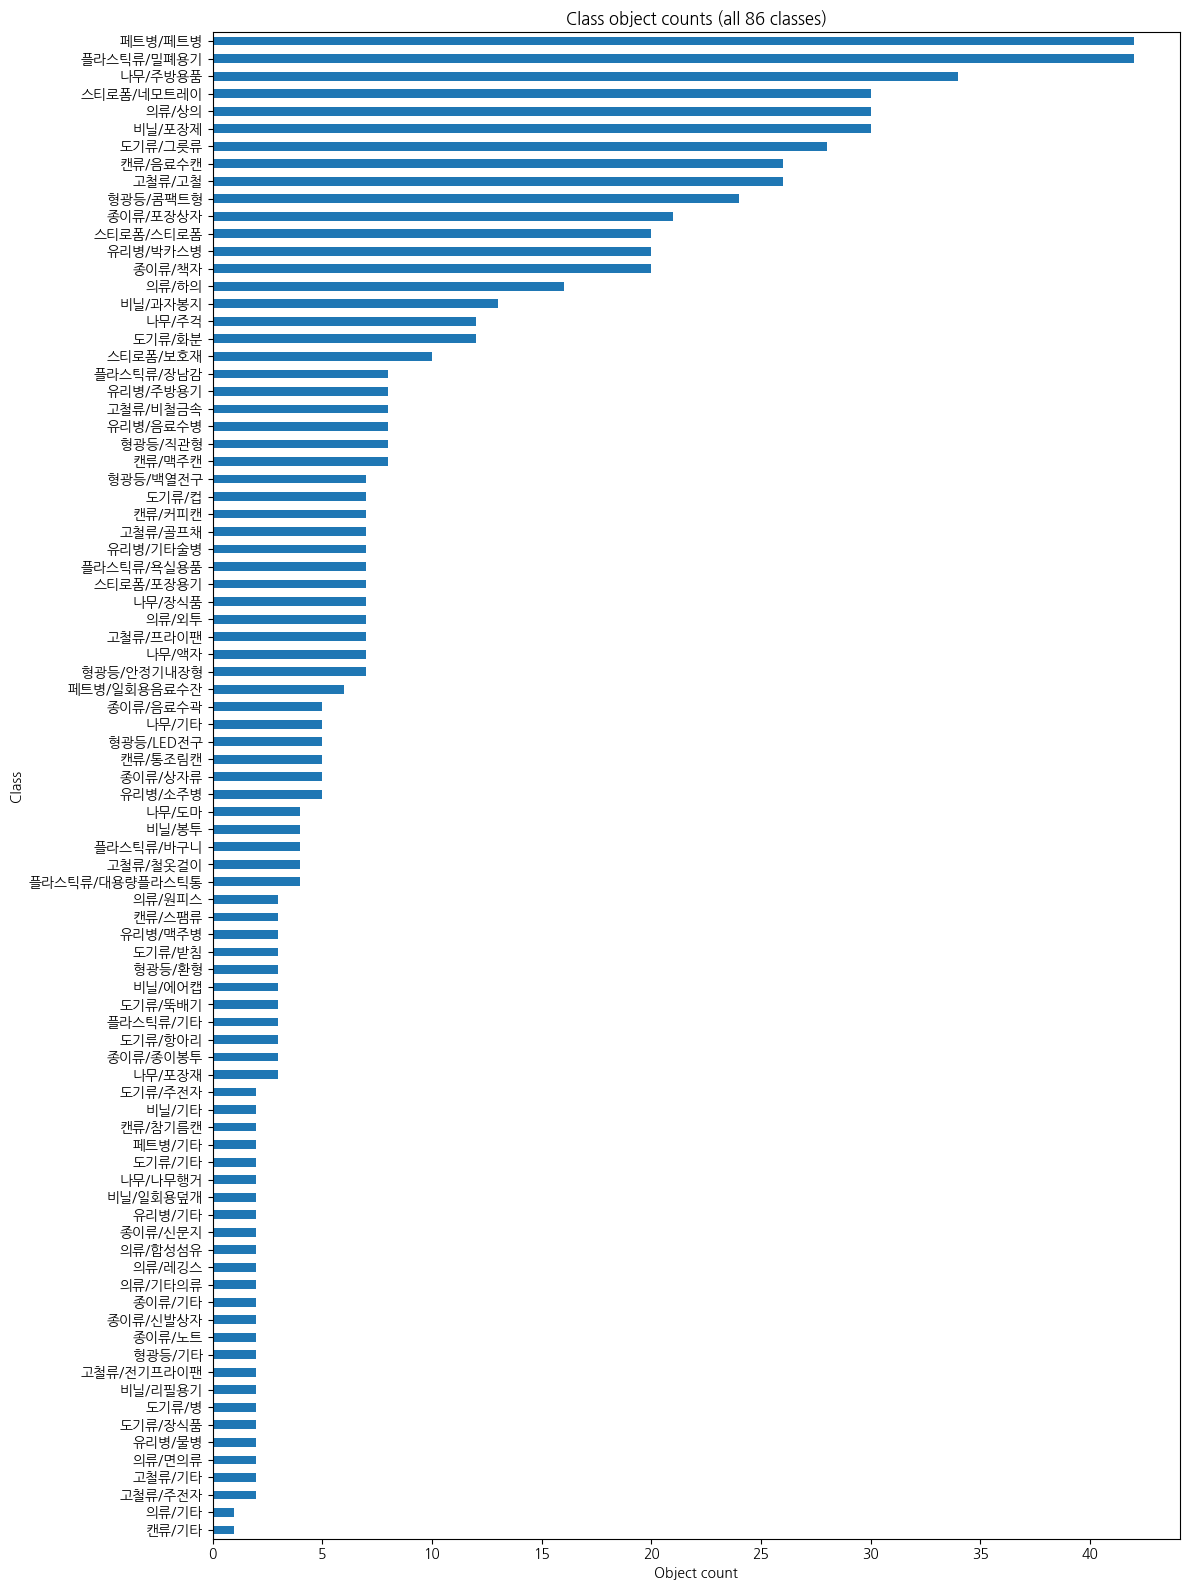

In [9]:
class_counts = object_df["class_name"].value_counts()

plt.figure(figsize=(12, 16))
class_counts.sort_values().plot(kind="barh")
plt.title("Class object counts (all 86 classes)")
plt.xlabel("Object count")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

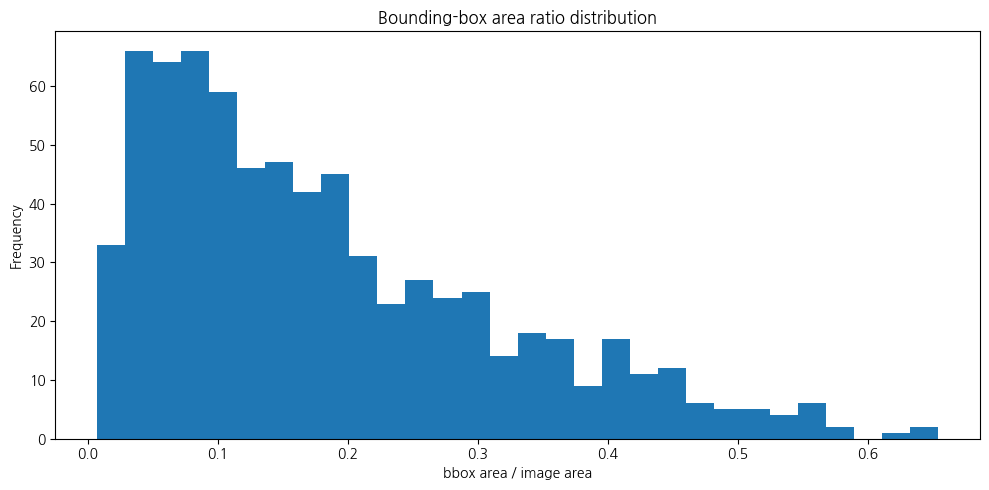

,bbox_area_ratio
count,727.000000
mean,0.183795
std,0.134045
min,0.007176
1%,0.015127
5%,0.029394
10%,0.040819
25%,0.076389
50%,0.149811
75%,0.257996


In [10]:
plt.figure(figsize=(10, 5))
object_df["bbox_area_ratio"].plot(kind="hist", bins=30)
plt.title("Bounding-box area ratio distribution")
plt.xlabel("bbox area / image area")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

display(object_df["bbox_area_ratio"].describe(percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]).to_frame())

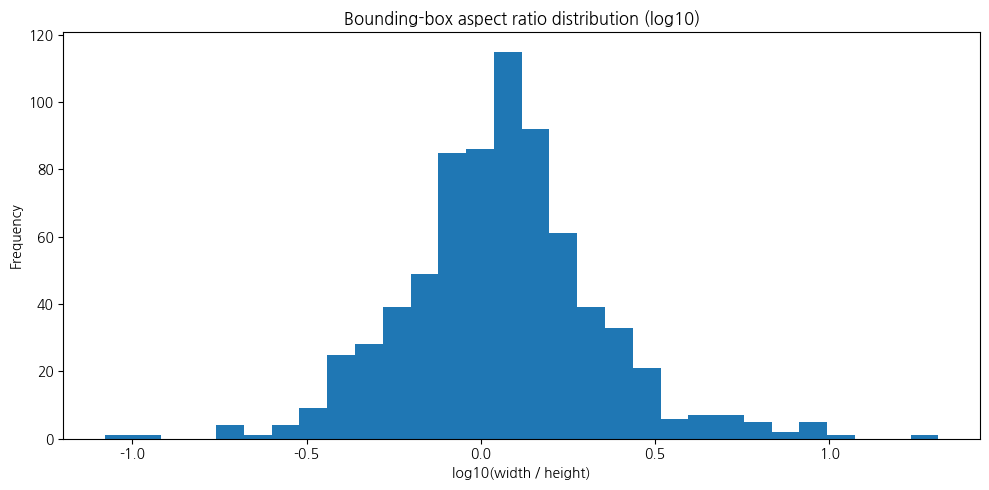

In [11]:
plt.figure(figsize=(10, 5))
np.log10(object_df["bbox_aspect_ratio"].clip(lower=1e-4)).plot(kind="hist", bins=30)
plt.title("Bounding-box aspect ratio distribution (log10)")
plt.xlabel("log10(width / height)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 8. 전처리된 YOLO bbox 샘플 확인

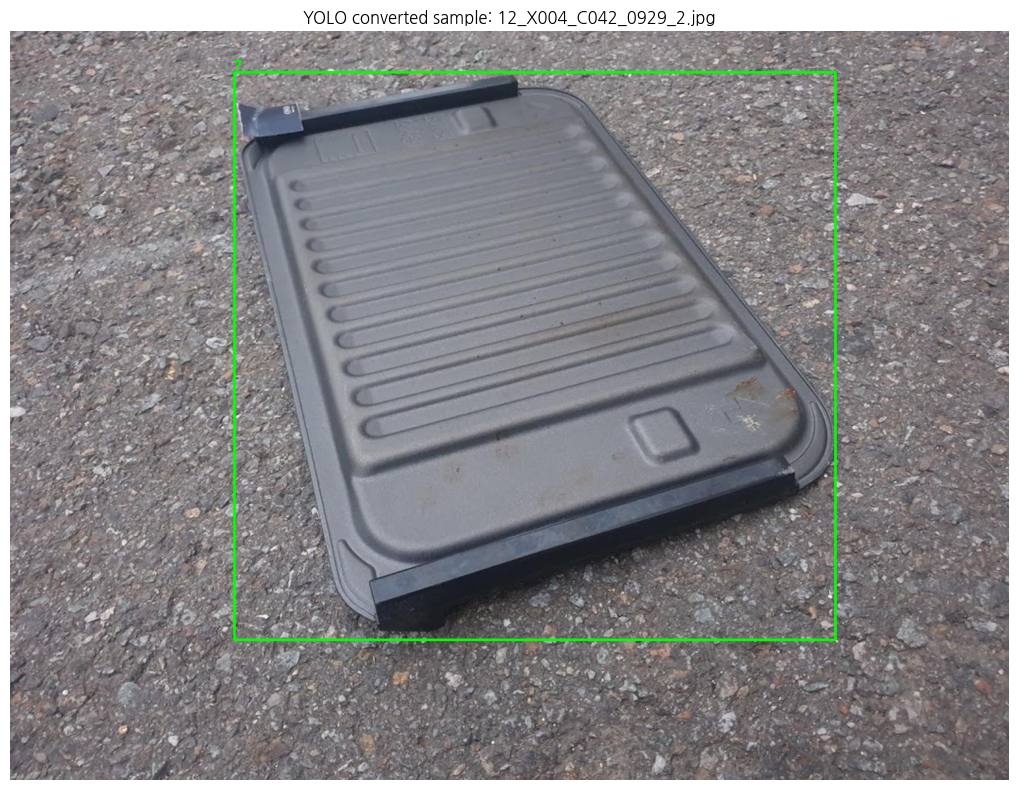

,class_id,class_name
0,7,고철류/프라이팬


In [12]:
def read_yolo_txt(label_path: Path, width: int, height: int):
    classes = []
    boxes = []
    text = label_path.read_text(encoding="utf-8").strip()
    if not text:
        return np.empty((0,), dtype=int), np.empty((0, 4), dtype=np.float32)

    for line in text.splitlines():
        cls, xc, yc, bw, bh = line.split()
        cls = int(cls)
        xc, yc, bw, bh = map(float, [xc, yc, bw, bh])

        x1 = (xc - bw / 2) * width
        y1 = (yc - bh / 2) * height
        x2 = (xc + bw / 2) * width
        y2 = (yc + bh / 2) * height

        classes.append(cls)
        boxes.append([x1, y1, x2, y2])

    return np.array(classes, dtype=int), np.array(boxes, dtype=np.float32)

def draw_boxes(image_bgr, boxes, classes, thickness=3):
    out = image_bgr.copy()
    h, w = out.shape[:2]

    for box, cls in zip(boxes, classes):
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), thickness)

        label = f"{cls}: {ID_TO_CLASS[int(cls)]}"
        # OpenCV 기본 폰트는 한글을 지원하지 않으므로 class id를 이미지에 표시하고,
        # class name은 아래 표에서 확인합니다.
        cv2.putText(
            out, str(cls), (x1, max(20, y1 - 7)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2, cv2.LINE_AA
        )
    return out

# 가능하면 프라이팬 샘플을 우선 사용
candidate = object_df[object_df["class_name"].eq("고철류/프라이팬")]
if len(candidate):
    sample_name = candidate.iloc[0]["image_name"]
    sample_split = candidate.iloc[0]["split"]
else:
    sample_name = image_df.iloc[0]["image_name"]
    sample_split = image_df.iloc[0]["split"]

sample_img_path = DATASET_DIR / "images" / sample_split / sample_name
sample_lbl_path = DATASET_DIR / "labels" / sample_split / f"{Path(sample_name).stem}.txt"

sample_img = cv2.imread(str(sample_img_path))
h, w = sample_img.shape[:2]
sample_cls, sample_boxes = read_yolo_txt(sample_lbl_path, w, h)
sample_drawn = draw_boxes(sample_img, sample_boxes, sample_cls)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(sample_drawn, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"YOLO converted sample: {sample_name}")
plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "class_id": sample_cls,
    "class_name": [ID_TO_CLASS[int(c)] for c in sample_cls],
}))

# 9. OpenCV 이미지 증강

## 구성

### Photometric
- brightness / contrast
- CLAHE
- Gaussian blur
- Gaussian noise

bbox 좌표는 변하지 않습니다.

### Geometric
- rotation
- translation
- scale
- mild perspective
- horizontal flip

기하 증강은 bbox의 네 모서리도 동일한 변환행렬로 변환한 후
새 axis-aligned bbox를 계산하고 이미지 밖 좌표를 clip합니다.

너무 많이 잘려 `visible ratio < 0.25`가 된 객체는 제거합니다.

In [13]:
def bbox_area_xyxy(boxes: np.ndarray) -> np.ndarray:
    if len(boxes) == 0:
        return np.empty((0,), dtype=np.float32)
    return (
        np.clip(boxes[:, 2] - boxes[:, 0], 0, None)
        * np.clip(boxes[:, 3] - boxes[:, 1], 0, None)
    )

def transform_boxes(
    boxes: np.ndarray,
    matrix: np.ndarray,
    width: int,
    height: int,
    min_visible: float = 0.25,
    min_size: float = 2.0,
):
    if len(boxes) == 0:
        return boxes.copy(), np.empty((0,), dtype=bool), np.empty((0,), dtype=np.float32)

    n = len(boxes)
    corners = np.stack(
        [
            boxes[:, [0, 1]],
            boxes[:, [2, 1]],
            boxes[:, [2, 3]],
            boxes[:, [0, 3]],
        ],
        axis=1,
    ).astype(np.float32)

    pts = corners.reshape(-1, 1, 2)

    if matrix.shape == (2, 3):
        transformed = cv2.transform(pts, matrix).reshape(n, 4, 2)
    else:
        transformed = cv2.perspectiveTransform(pts, matrix).reshape(n, 4, 2)

    raw = np.column_stack([
        transformed[:, :, 0].min(axis=1),
        transformed[:, :, 1].min(axis=1),
        transformed[:, :, 0].max(axis=1),
        transformed[:, :, 1].max(axis=1),
    ]).astype(np.float32)

    raw_area = bbox_area_xyxy(raw)

    clipped = raw.copy()
    clipped[:, [0, 2]] = np.clip(clipped[:, [0, 2]], 0, width)
    clipped[:, [1, 3]] = np.clip(clipped[:, [1, 3]], 0, height)

    clipped_area = bbox_area_xyxy(clipped)
    visible = clipped_area / np.maximum(raw_area, 1e-6)

    keep = (
        ((clipped[:, 2] - clipped[:, 0]) >= min_size)
        & ((clipped[:, 3] - clipped[:, 1]) >= min_size)
        & (visible >= min_visible)
    )

    return clipped[keep], keep, visible

def aug_photometric(image, boxes, classes, rng):
    out = image.copy()

    alpha = float(rng.uniform(0.80, 1.20))
    beta = float(rng.uniform(-25, 25))
    out = np.clip(out.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)

    if rng.random() < 0.40:
        lab = cv2.cvtColor(out, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(
            clipLimit=float(rng.uniform(1.5, 3.0)),
            tileGridSize=(8, 8),
        )
        l = clahe.apply(l)
        out = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)

    if rng.random() < 0.25:
        k = int(rng.choice([3, 5]))
        out = cv2.GaussianBlur(out, (k, k), 0)

    if rng.random() < 0.30:
        sigma = float(rng.uniform(3, 12))
        noise = rng.normal(0, sigma, out.shape).astype(np.float32)
        out = np.clip(out.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    return out, boxes.copy(), classes.copy()

def aug_affine(image, boxes, classes, rng):
    h, w = image.shape[:2]

    angle = float(rng.uniform(-12, 12))
    scale = float(rng.uniform(0.88, 1.12))
    tx = float(rng.uniform(-0.06, 0.06) * w)
    ty = float(rng.uniform(-0.06, 0.06) * h)

    matrix = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
    matrix[0, 2] += tx
    matrix[1, 2] += ty

    out = cv2.warpAffine(
        image, matrix, (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT_101,
    )
    new_boxes, keep, _ = transform_boxes(boxes, matrix, w, h)
    return out, new_boxes, classes[keep]

def aug_perspective(image, boxes, classes, rng):
    h, w = image.shape[:2]
    jitter = 0.035

    src = np.array([
        [0, 0],
        [w - 1, 0],
        [w - 1, h - 1],
        [0, h - 1],
    ], dtype=np.float32)

    dst = src.copy()
    dst[:, 0] += rng.uniform(-jitter * w, jitter * w, 4)
    dst[:, 1] += rng.uniform(-jitter * h, jitter * h, 4)

    matrix = cv2.getPerspectiveTransform(src, dst.astype(np.float32))

    out = cv2.warpPerspective(
        image, matrix, (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT_101,
    )
    new_boxes, keep, _ = transform_boxes(boxes, matrix, w, h)
    return out, new_boxes, classes[keep]

def aug_horizontal_flip(image, boxes, classes):
    h, w = image.shape[:2]
    out = cv2.flip(image, 1)

    new_boxes = boxes.copy()
    if len(new_boxes):
        x1 = boxes[:, 0].copy()
        x2 = boxes[:, 2].copy()
        new_boxes[:, 0] = w - x2
        new_boxes[:, 2] = w - x1

    return out, new_boxes, classes.copy()

def aug_combined(image, boxes, classes, rng):
    out, b, c = aug_photometric(image, boxes, classes, rng)
    out, b, c = aug_affine(out, b, c, rng)

    if rng.random() < 0.35:
        out, b, c = aug_perspective(out, b, c, rng)

    if rng.random() < 0.50:
        out, b, c = aug_horizontal_flip(out, b, c)

    return out, b, c

## 10. OpenCV 증강 결과 시각화

한 샘플에 각 기법을 적용하고 bbox가 함께 이동하는지 확인합니다.

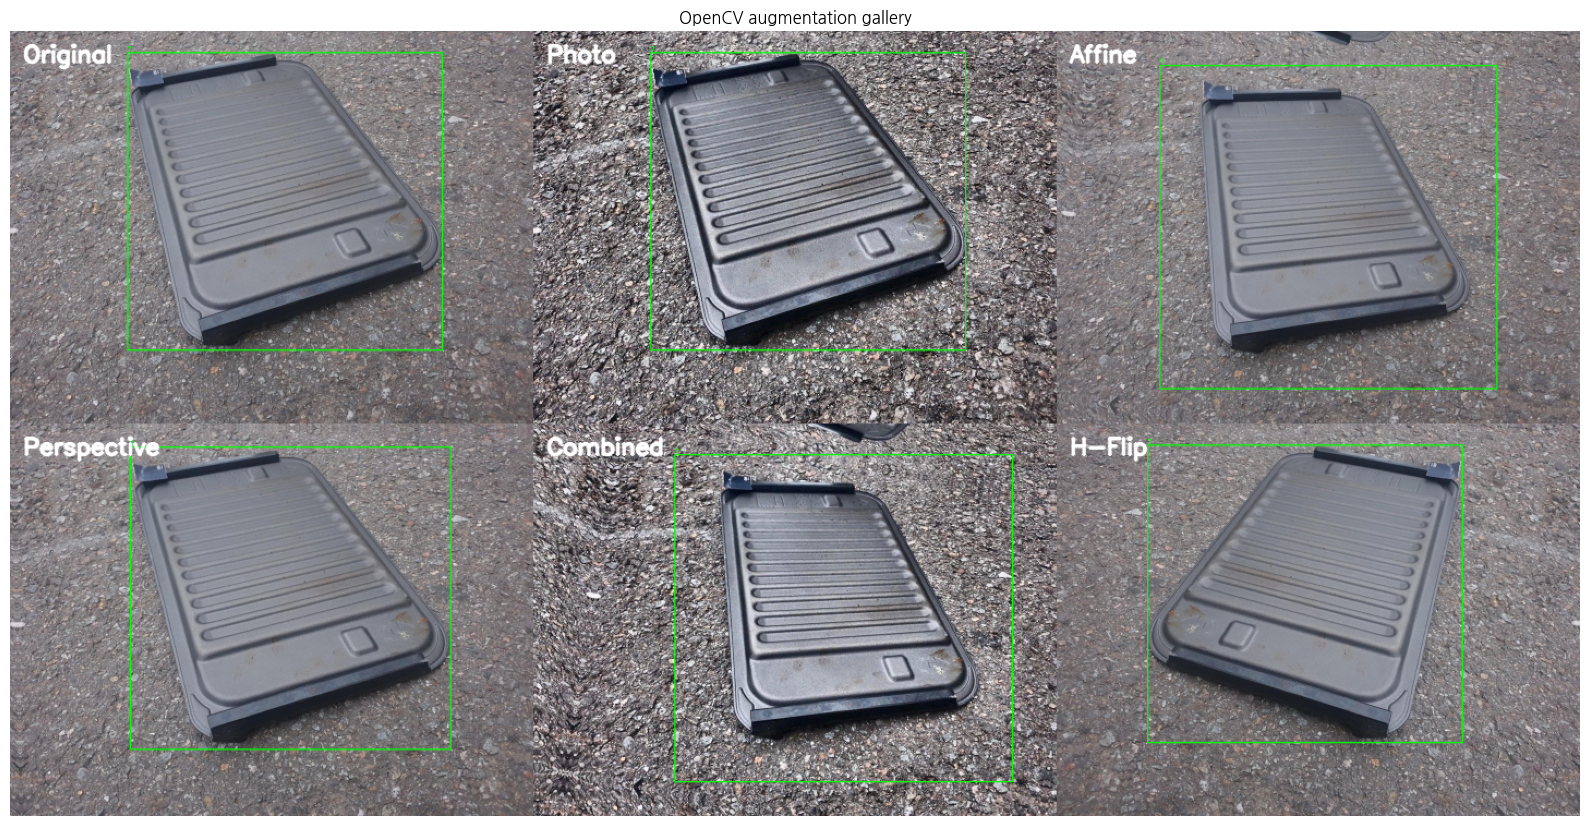

In [14]:
def resize_for_gallery(img, target_w=480, target_h=360):
    h, w = img.shape[:2]
    scale = min(target_w / w, target_h / h)
    nw, nh = max(1, int(w * scale)), max(1, int(h * scale))
    resized = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_AREA)
    canvas = np.full((target_h, target_w, 3), 30, dtype=np.uint8)
    x0 = (target_w - nw) // 2
    y0 = (target_h - nh) // 2
    canvas[y0:y0 + nh, x0:x0 + nw] = resized
    return canvas

def make_gallery(items, cols=3):
    # items: [(title, bgr_image), ...]
    thumbs = []
    for title, img in items:
        thumb = resize_for_gallery(img)
        cv2.putText(
            thumb, title, (12, 28),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7,
            (255, 255, 255), 2, cv2.LINE_AA
        )
        thumbs.append(thumb)

    rows = []
    for i in range(0, len(thumbs), cols):
        row = thumbs[i:i + cols]
        while len(row) < cols:
            row.append(np.full_like(thumbs[0], 30))
        rows.append(cv2.hconcat(row))
    return cv2.vconcat(rows)

base_img = cv2.imread(str(sample_img_path))
h, w = base_img.shape[:2]
base_cls, base_boxes = read_yolo_txt(sample_lbl_path, w, h)

gallery_items = [("Original", draw_boxes(base_img, base_boxes, base_cls))]

policies = {
    "Photo": aug_photometric,
    "Affine": aug_affine,
    "Perspective": aug_perspective,
    "Combined": aug_combined,
}

for idx, (name, fn) in enumerate(policies.items(), start=1):
    rng = np.random.default_rng(SEED + idx)
    aug_img, aug_boxes, aug_cls = fn(base_img, base_boxes, base_cls, rng)
    gallery_items.append((name, draw_boxes(aug_img, aug_boxes, aug_cls)))

flip_img, flip_boxes, flip_cls = aug_horizontal_flip(base_img, base_boxes, base_cls)
gallery_items.append(("H-Flip", draw_boxes(flip_img, flip_boxes, flip_cls)))

gallery = make_gallery(gallery_items, cols=3)

plt.figure(figsize=(16, 10))
plt.imshow(cv2.cvtColor(gallery, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("OpenCV augmentation gallery")
plt.tight_layout()
plt.show()

## 11. OpenCV 기하 증강 bbox 안정성 QA

실제 이미지를 전부 warp하지 않고 bbox 좌표에 동일한 랜덤 변환을 적용하여,
객체가 지나치게 사라지는 정책인지 빠르게 확인합니다.

**목표:** box retention이 지나치게 낮으면 증강 강도를 줄입니다.

In [15]:
def qa_box_policy(policy_name: str, image_df: pd.DataFrame, object_df: pd.DataFrame):
    total_in = 0
    total_out = 0
    clipped = 0
    dropped = 0
    out_area_ratios = []

    grouped = object_df.groupby(["split", "image_name"])

    for row in image_df[image_df["split"].eq("train")].itertuples(index=False):
        key = ("train", row.image_name)
        if key not in grouped.groups:
            continue

        g = grouped.get_group(key)
        boxes = g[["x1", "y1", "x2", "y2"]].to_numpy(np.float32)
        total_in += len(boxes)

        seed = int(hashlib.sha1(f"{policy_name}|{row.image_name}".encode()).hexdigest()[:8], 16)
        rng = np.random.default_rng(seed)

        if policy_name == "photo":
            b2 = boxes.copy()
            keep = np.ones(len(boxes), dtype=bool)
            visible = np.ones(len(boxes), dtype=np.float32)

        elif policy_name == "affine":
            angle = float(rng.uniform(-12, 12))
            scale = float(rng.uniform(0.88, 1.12))
            tx = float(rng.uniform(-0.06, 0.06) * row.width)
            ty = float(rng.uniform(-0.06, 0.06) * row.height)
            matrix = cv2.getRotationMatrix2D((row.width / 2, row.height / 2), angle, scale)
            matrix[0, 2] += tx
            matrix[1, 2] += ty
            b2, keep, visible = transform_boxes(boxes, matrix, row.width, row.height)

        elif policy_name == "perspective":
            jitter = 0.035
            src = np.array([
                [0, 0],
                [row.width - 1, 0],
                [row.width - 1, row.height - 1],
                [0, row.height - 1],
            ], dtype=np.float32)
            dst = src.copy()
            dst[:, 0] += rng.uniform(-jitter * row.width, jitter * row.width, 4)
            dst[:, 1] += rng.uniform(-jitter * row.height, jitter * row.height, 4)
            matrix = cv2.getPerspectiveTransform(src, dst.astype(np.float32))
            b2, keep, visible = transform_boxes(boxes, matrix, row.width, row.height)

        else:
            raise ValueError(policy_name)

        total_out += len(b2)
        dropped += int((~keep).sum())
        if len(visible):
            clipped += int((visible[keep] < 0.999).sum())

        if len(b2):
            out_area_ratios.extend(
                (bbox_area_xyxy(b2) / (row.width * row.height)).tolist()
            )

    return {
        "policy": policy_name,
        "input_boxes": total_in,
        "output_boxes": total_out,
        "retention_pct": 100 * total_out / max(total_in, 1),
        "clipped_boxes": clipped,
        "dropped_boxes": dropped,
        "mean_bbox_area_ratio": np.mean(out_area_ratios) if out_area_ratios else np.nan,
    }

cv2_qa = pd.DataFrame([
    qa_box_policy("photo", image_df, object_df),
    qa_box_policy("affine", image_df, object_df),
    qa_box_policy("perspective", image_df, object_df),
])

display(cv2_qa)
cv2_qa.to_csv(REPORT_DIR / "cv2_bbox_augmentation_qa.csv", index=False, encoding="utf-8-sig")

,policy,input_boxes,output_boxes,retention_pct,clipped_boxes,dropped_boxes,mean_bbox_area_ratio
0,photo,602,602,100.0,0,0,0.182548
1,affine,602,602,100.0,46,0,0.226110
2,perspective,602,602,100.0,5,0,0.190456


## 12. OpenCV 오프라인 증강 데이터 생성

여기서는 원본 train을 유지하면서 `train_cv2`를 추가합니다.

```text
images/train       # 원본
images/train_cv2   # OpenCV 증강본
labels/train
labels/train_cv2
```

Validation은 그대로 `images/val`만 사용합니다.

`data_cv2.yaml`의 train 경로는 원본 + 증강본 두 디렉터리를 함께 가리킵니다.

In [16]:
def xyxy_to_yolo_lines(classes, boxes, width, height):
    lines = []
    for cls, (x1, y1, x2, y2) in zip(classes, boxes):
        xc, yc, bw, bh = xyxy_to_yolo(x1, y1, x2, y2, width, height)
        lines.append(f"{int(cls)} {xc:.8f} {yc:.8f} {bw:.8f} {bh:.8f}")
    return lines

def build_cv2_augmented_train(copies_per_image=1, overwrite=False):
    out_img_dir = DATASET_DIR / "images" / "train_cv2"
    out_lbl_dir = DATASET_DIR / "labels" / "train_cv2"

    if overwrite:
        shutil.rmtree(out_img_dir, ignore_errors=True)
        shutil.rmtree(out_lbl_dir, ignore_errors=True)

    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)

    rows = []

    for img_path in sorted((DATASET_DIR / "images" / "train").glob("*.*")):
        label_path = DATASET_DIR / "labels" / "train" / f"{img_path.stem}.txt"
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        h, w = img.shape[:2]
        classes, boxes = read_yolo_txt(label_path, w, h)

        for copy_idx in range(copies_per_image):
            seed_text = f"{SEED}|{img_path.name}|{copy_idx}"
            seed = int(hashlib.sha1(seed_text.encode()).hexdigest()[:8], 16)
            rng = np.random.default_rng(seed)

            aug_img, aug_boxes, aug_classes = aug_combined(img, boxes, classes, rng)

            # 원래 객체가 있었는데 증강 후 bbox가 전부 사라지면 해당 증강 샘플은 저장하지 않음
            if len(classes) > 0 and len(aug_classes) == 0:
                continue

            suffix = f"__cv2aug{copy_idx + 1}"
            out_img = out_img_dir / f"{img_path.stem}{suffix}{img_path.suffix.lower()}"
            out_lbl = out_lbl_dir / f"{img_path.stem}{suffix}.txt"

            ok = cv2.imwrite(str(out_img), aug_img)
            if not ok:
                raise IOError(f"cv2.imwrite failed: {out_img}")

            out_lbl.write_text(
                "\n".join(xyxy_to_yolo_lines(aug_classes, aug_boxes, w, h)),
                encoding="utf-8",
            )

            rows.append({
                "source_image": img_path.name,
                "aug_image": out_img.name,
                "source_objects": len(classes),
                "aug_objects": len(aug_classes),
            })

    report = pd.DataFrame(rows)
    report.to_csv(REPORT_DIR / "cv2_offline_generation.csv", index=False, encoding="utf-8-sig")

    data_cv2 = {
        "path": str(DATASET_DIR.resolve()),
        "train": ["images/train", "images/train_cv2"],
        "val": "images/val",
        "names": {i: name for i, name in enumerate(CLASS_NAMES)},
    }
    with open(DATASET_DIR / "data_cv2.yaml", "w", encoding="utf-8") as f:
        yaml.safe_dump(data_cv2, f, allow_unicode=True, sort_keys=False)

    return report

# 실제 YOLO 실험 전에 생성됩니다.
# 필요하면 지금 바로 실행:
# cv2_generation_report = build_cv2_augmented_train(CV2_AUG_COPIES, overwrite=True)
# display(cv2_generation_report.describe(include="all"))

# 13. YOLO baseline

## 공정한 비교 기준

모든 실험에서 아래를 동일하게 유지합니다.

- 같은 pretrained nano 모델
- 같은 train/validation split
- 같은 `imgsz`, batch, epoch
- 같은 seed
- 매 실험마다 **새 모델 객체**에서 시작
- Validation에는 증강 적용 안 함
- mAP50-95를 1차 지표로 사용
- mAP50 / Precision / Recall / 시간도 함께 비교

### Baseline을 두 개로 구분

- `E00_no_aug`: augmentation 효과를 보기 위한 엄격한 control
- `E01_yolo_default`: Ultralytics 기본 augmentation을 그대로 사용하는 실용 baseline

In [17]:
try:
    import torch
    from ultralytics import YOLO
    import ultralytics
    from ultralytics.cfg import DEFAULT_CFG_DICT

    if torch.cuda.is_available():
        DEVICE = 0
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        DEVICE = "mps"
    else:
        DEVICE = "cpu"

    print("Ultralytics:", ultralytics.__version__)
    print("Torch:", torch.__version__)
    print("Device:", DEVICE)

except ImportError as e:
    YOLO = None
    DEVICE = "cpu"
    print(
        "Ultralytics가 설치되어 있지 않습니다.\n"
        "프로젝트 터미널에서 `uv add ultralytics`를 실행한 뒤 커널을 재시작하세요.\n"
        f"Original error: {e}"
    )

Ultralytics가 설치되어 있지 않습니다.
프로젝트 터미널에서 `uv add ultralytics`를 실행한 뒤 커널을 재시작하세요.
Original error: No module named 'ultralytics'


In [18]:
DATA_YAML = DATASET_DIR / "data.yaml"
DATA_CV2_YAML = DATASET_DIR / "data_cv2.yaml"

NO_AUG = {
    "hsv_h": 0.0,
    "hsv_s": 0.0,
    "hsv_v": 0.0,
    "degrees": 0.0,
    "translate": 0.0,
    "scale": 0.0,
    "shear": 0.0,
    "perspective": 0.0,
    "flipud": 0.0,
    "fliplr": 0.0,
    "bgr": 0.0,
    "mosaic": 0.0,
    "mixup": 0.0,
    "cutmix": 0.0,
    "copy_paste": 0.0,
}

HSV_FLIP = {
    **NO_AUG,
    "hsv_h": 0.015,
    "hsv_s": 0.50,
    "hsv_v": 0.35,
    "fliplr": 0.50,
}

GEO_LIGHT = {
    **NO_AUG,
    "degrees": 10.0,
    "translate": 0.08,
    "scale": 0.25,
    "shear": 2.0,
    "perspective": 0.0003,
    "fliplr": 0.50,
}

HSV_GEO = {
    **GEO_LIGHT,
    "hsv_h": 0.015,
    "hsv_s": 0.50,
    "hsv_v": 0.35,
}

MOSAIC_LIGHT = {
    **HSV_GEO,
    "mosaic": 0.70,
}

MOSAIC_MIX = {
    **HSV_GEO,
    "mosaic": 0.70,
    "mixup": 0.10,
    "cutmix": 0.10,
}

CV2_PLUS_YOLO_LIGHT = {
    **NO_AUG,
    "hsv_h": 0.010,
    "hsv_s": 0.30,
    "hsv_v": 0.25,
    "degrees": 5.0,
    "translate": 0.05,
    "scale": 0.15,
    "fliplr": 0.35,
}

EXPERIMENTS = [
    {
        "id": "E00",
        "name": "no_aug_control",
        "data": DATA_YAML,
        "aug": NO_AUG,
        "description": "모든 제어 가능한 YOLO 증강 off",
    },
    {
        "id": "E01",
        "name": "yolo_default",
        "data": DATA_YAML,
        "aug": None,  # Ultralytics default 그대로
        "description": "Ultralytics 기본 증강",
    },
    {
        "id": "E02",
        "name": "hsv_flip",
        "data": DATA_YAML,
        "aug": HSV_FLIP,
        "description": "HSV + horizontal flip",
    },
    {
        "id": "E03",
        "name": "geo_light",
        "data": DATA_YAML,
        "aug": GEO_LIGHT,
        "description": "rotate/translate/scale/shear/perspective + flip",
    },
    {
        "id": "E04",
        "name": "hsv_geo",
        "data": DATA_YAML,
        "aug": HSV_GEO,
        "description": "HSV + light geometry",
    },
    {
        "id": "E05",
        "name": "mosaic_light",
        "data": DATA_YAML,
        "aug": MOSAIC_LIGHT,
        "description": "HSV + geometry + mosaic",
    },
    {
        "id": "E06",
        "name": "mosaic_mix_cutmix",
        "data": DATA_YAML,
        "aug": MOSAIC_MIX,
        "description": "HSV + geometry + mosaic + mixup + cutmix",
    },
    {
        "id": "E07",
        "name": "cv2_combined",
        "data": DATA_CV2_YAML,
        "aug": NO_AUG,
        "description": "원본 + OpenCV offline combined, YOLO 증강 off",
    },
    {
        "id": "E08",
        "name": "cv2_plus_yolo_light",
        "data": DATA_CV2_YAML,
        "aug": CV2_PLUS_YOLO_LIGHT,
        "description": "원본 + OpenCV offline + 약한 YOLO 증강",
    },
]

planned = pd.DataFrame([
    {
        "id": e["id"],
        "name": e["name"],
        "data": Path(e["data"]).name,
        "description": e["description"],
        "augmentation_args": "Ultralytics defaults" if e["aug"] is None else json.dumps(e["aug"], ensure_ascii=False),
    }
    for e in EXPERIMENTS
])

display(planned)

,id,name,data,description,augmentation_args
0,E00,no_aug_control,data.yaml,모든 제어 가능한 YOLO 증강 off,"{""hsv_h"": 0.0, ""hsv_s"": 0.0, ""hsv_v"": 0.0, ""de..."
1,E01,yolo_default,data.yaml,Ultralytics 기본 증강,Ultralytics defaults
2,E02,hsv_flip,data.yaml,HSV + horizontal flip,"{""hsv_h"": 0.015, ""hsv_s"": 0.5, ""hsv_v"": 0.35, ..."
3,E03,geo_light,data.yaml,rotate/translate/scale/shear/perspective + flip,"{""hsv_h"": 0.0, ""hsv_s"": 0.0, ""hsv_v"": 0.0, ""de..."
4,E04,hsv_geo,data.yaml,HSV + light geometry,"{""hsv_h"": 0.015, ""hsv_s"": 0.5, ""hsv_v"": 0.35, ..."
5,E05,mosaic_light,data.yaml,HSV + geometry + mosaic,"{""hsv_h"": 0.015, ""hsv_s"": 0.5, ""hsv_v"": 0.35, ..."
6,E06,mosaic_mix_cutmix,data.yaml,HSV + geometry + mosaic + mixup + cutmix,"{""hsv_h"": 0.015, ""hsv_s"": 0.5, ""hsv_v"": 0.35, ..."
7,E07,cv2_combined,data_cv2.yaml,"원본 + OpenCV offline combined, YOLO 증강 off","{""hsv_h"": 0.0, ""hsv_s"": 0.0, ""hsv_v"": 0.0, ""de..."
8,E08,cv2_plus_yolo_light,data_cv2.yaml,원본 + OpenCV offline + 약한 YOLO 증강,"{""hsv_h"": 0.01, ""hsv_s"": 0.3, ""hsv_v"": 0.25, ""..."


## 14. 단일 YOLO baseline 실행 예시

아래 코드는 baseline 로직을 명확히 보기 위한 셀입니다.
전체 비교는 다음 섹션의 experiment runner가 자동으로 수행합니다.

In [19]:
def filter_supported_args(args: dict | None):
    if args is None or YOLO is None:
        return {} if args is None else args

    supported = set(DEFAULT_CFG_DICT.keys())
    unknown = sorted(set(args) - supported)

    if unknown:
        print("Installed Ultralytics에서 지원하지 않아 제외할 augmentation args:", unknown)

    return {k: v for k, v in args.items() if k in supported}

def baseline_example():
    if YOLO is None:
        raise RuntimeError("먼저 ultralytics를 설치하세요.")

    model = YOLO(MODEL_NAME)
    model.train(
        data=str(DATA_YAML),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        device=DEVICE,
        workers=WORKERS,
        seed=SEED,
        deterministic=True,
        project=str(RUNS_DIR),
        name="baseline_example",
        plots=True,
        **filter_supported_args(NO_AUG),
    )

# 실행하고 싶으면:
# baseline_example()

# 15. 여러 증강 조합 자동 실험

`RUN_TRAINING = True`로 바꾸고 실행하면 됩니다.

- `FAST_MODE=True`: E00/E01/E04/E05 4개만 빠르게 sanity check
- `FAST_MODE=False`: E00~E08 전체 비교

E07/E08이 포함되면 OpenCV offline augmented train set을 자동 생성합니다.

In [20]:
def extract_box_metrics(metrics):
    box = metrics.box
    return {
        "precision": float(box.mp),
        "recall": float(box.mr),
        "mAP50": float(box.map50),
        "mAP50_95": float(box.map),
    }

def train_one_experiment(exp, seed=SEED):
    if YOLO is None:
        raise RuntimeError("ultralytics를 설치한 뒤 실행하세요.")

    data_path = Path(exp["data"])

    # OpenCV dataset이 필요한 실험이면 자동 생성
    if data_path.name == "data_cv2.yaml" and not data_path.exists():
        print("Generating OpenCV offline augmented training set...")
        report = build_cv2_augmented_train(CV2_AUG_COPIES, overwrite=True)
        print("Generated augmented images:", len(report))

    run_name = f'{exp["id"]}_{exp["name"]}_seed{seed}'
    model = YOLO(MODEL_NAME)

    train_kwargs = dict(
        data=str(data_path),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        device=DEVICE,
        workers=WORKERS,
        seed=seed,
        deterministic=True,
        patience=PATIENCE,
        project=str(RUNS_DIR),
        name=run_name,
        exist_ok=True,
        plots=True,
        save=True,
        verbose=True,
    )

    if exp["aug"] is not None:
        train_kwargs.update(filter_supported_args(exp["aug"]))

    started = time.perf_counter()
    train_result = model.train(**train_kwargs)
    elapsed_min = (time.perf_counter() - started) / 60.0

    save_dir = Path(train_result.save_dir)
    best_pt = save_dir / "weights" / "best.pt"

    if not best_pt.exists():
        raise FileNotFoundError(best_pt)

    best_model = YOLO(str(best_pt))
    val_metrics = best_model.val(
        data=str(data_path),
        split="val",
        imgsz=IMGSZ,
        batch=BATCH,
        device=DEVICE,
        workers=WORKERS,
        plots=True,
        verbose=False,
    )

    row = {
        "id": exp["id"],
        "name": exp["name"],
        "description": exp["description"],
        "seed": seed,
        "data_yaml": data_path.name,
        "epochs_requested": EPOCHS,
        "train_minutes": elapsed_min,
        "save_dir": str(save_dir),
        "best_pt": str(best_pt),
        **extract_box_metrics(val_metrics),
    }
    return row

def run_experiments():
    selected = EXPERIMENTS
    if FAST_MODE:
        keep = {"E00", "E01", "E04", "E05"}
        selected = [e for e in EXPERIMENTS if e["id"] in keep]

    rows = []
    for idx, exp in enumerate(selected, 1):
        print("=" * 90)
        print(f"[{idx}/{len(selected)}] {exp['id']} - {exp['name']}")
        try:
            row = train_one_experiment(exp, seed=SEED)
            rows.append(row)
            display(pd.DataFrame(rows))
        except Exception as e:
            print(f"FAILED: {exp['id']} {exp['name']} -> {repr(e)}")
            rows.append({
                "id": exp["id"],
                "name": exp["name"],
                "description": exp["description"],
                "seed": SEED,
                "error": repr(e),
            })

        pd.DataFrame(rows).to_csv(
            REPORT_DIR / "experiment_summary.csv",
            index=False,
            encoding="utf-8-sig",
        )

    return pd.DataFrame(rows)

if RUN_TRAINING:
    experiment_summary = run_experiments()
else:
    print("RUN_TRAINING=False: 학습은 실행하지 않았습니다.")
    print("실행하려면 설정 셀에서 RUN_TRAINING=True로 바꾸고 이 셀부터 실행하세요.")

RUN_TRAINING=False: 학습은 실행하지 않았습니다.
실행하려면 설정 셀에서 RUN_TRAINING=True로 바꾸고 이 셀부터 실행하세요.


# 16. 실험 결과 표 정리

실험이 완료되면 자동 생성된 `experiment_summary.csv`를 읽어
`mAP50-95` 순으로 정렬합니다.

In [21]:
SUMMARY_CSV = REPORT_DIR / "experiment_summary.csv"

if SUMMARY_CSV.exists():
    results_df = pd.read_csv(SUMMARY_CSV)
    metric_cols = ["precision", "recall", "mAP50", "mAP50_95"]

    valid_results = results_df.dropna(subset=["mAP50_95"]).copy()

    if len(valid_results):
        valid_results = valid_results.sort_values("mAP50_95", ascending=False)

        baseline_rows = valid_results[valid_results["id"].eq("E00")]
        baseline_map = baseline_rows.iloc[0]["mAP50_95"] if len(baseline_rows) else np.nan
        valid_results["mAP50_95_delta_vs_E00"] = valid_results["mAP50_95"] - baseline_map

        display(
            valid_results[
                [
                    "id", "name", "precision", "recall",
                    "mAP50", "mAP50_95", "mAP50_95_delta_vs_E00",
                    "train_minutes", "best_pt",
                ]
            ]
        )
    else:
        print("성공적으로 완료된 YOLO 실험이 없습니다.")
        display(results_df)
else:
    print("아직 experiment_summary.csv가 없습니다.")
    display(planned[["id", "name", "data", "description"]])

아직 experiment_summary.csv가 없습니다.


,id,name,data,description
0,E00,no_aug_control,data.yaml,모든 제어 가능한 YOLO 증강 off
1,E01,yolo_default,data.yaml,Ultralytics 기본 증강
2,E02,hsv_flip,data.yaml,HSV + horizontal flip
3,E03,geo_light,data.yaml,rotate/translate/scale/shear/perspective + flip
4,E04,hsv_geo,data.yaml,HSV + light geometry
5,E05,mosaic_light,data.yaml,HSV + geometry + mosaic
6,E06,mosaic_mix_cutmix,data.yaml,HSV + geometry + mosaic + mixup + cutmix
7,E07,cv2_combined,data_cv2.yaml,"원본 + OpenCV offline combined, YOLO 증강 off"
8,E08,cv2_plus_yolo_light,data_cv2.yaml,원본 + OpenCV offline + 약한 YOLO 증강


# 17. 실험 결과 시각화

In [22]:
if SUMMARY_CSV.exists():
    results_df = pd.read_csv(SUMMARY_CSV)
    valid_results = results_df.dropna(subset=["mAP50_95"]).copy()

    if len(valid_results):
        plot_df = valid_results.sort_values("mAP50_95", ascending=True)

        plt.figure(figsize=(10, 6))
        plt.barh(plot_df["name"], plot_df["mAP50_95"])
        plt.xlabel("mAP50-95")
        plt.ylabel("Experiment")
        plt.title("Augmentation experiment: mAP50-95")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 6))
        plt.barh(plot_df["name"], plot_df["mAP50"])
        plt.xlabel("mAP50")
        plt.ylabel("Experiment")
        plt.title("Augmentation experiment: mAP50")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 6))
        x = np.arange(len(plot_df))
        width = 0.38
        plt.bar(x - width / 2, plot_df["precision"], width=width, label="Precision")
        plt.bar(x + width / 2, plot_df["recall"], width=width, label="Recall")
        plt.xticks(x, plot_df["name"], rotation=45, ha="right")
        plt.ylabel("Score")
        plt.title("Precision / Recall")
        plt.legend()
        plt.tight_layout()
        plt.show()

        if "train_minutes" in plot_df:
            plt.figure(figsize=(9, 6))
            plt.scatter(plot_df["train_minutes"], plot_df["mAP50_95"])
            for _, r in plot_df.iterrows():
                plt.annotate(r["name"], (r["train_minutes"], r["mAP50_95"]))
            plt.xlabel("Training minutes")
            plt.ylabel("mAP50-95")
            plt.title("Accuracy vs training time")
            plt.tight_layout()
            plt.show()

# 18. Best run의 Ultralytics 시각 결과 확인

Ultralytics가 생성한 파일이 존재하면 다음을 표시합니다.

- `results.png`: train/val loss 및 metric curve
- `PR_curve.png`
- `confusion_matrix_normalized.png`
- validation batch prediction 이미지

In [23]:
def show_if_exists(path: Path, width=1000):
    if path.exists():
        print(path)
        display(IPImage(filename=str(path), width=width))
    else:
        print("not found:", path)

if SUMMARY_CSV.exists():
    results_df = pd.read_csv(SUMMARY_CSV)
    valid_results = results_df.dropna(subset=["mAP50_95"]).copy()

    if len(valid_results):
        best = valid_results.sort_values("mAP50_95", ascending=False).iloc[0]
        best_dir = Path(best["save_dir"])

        print("Best experiment:", best["id"], best["name"])
        print("mAP50-95:", best["mAP50_95"])
        print("best.pt:", best["best_pt"])

        for filename in [
            "results.png",
            "PR_curve.png",
            "confusion_matrix_normalized.png",
            "val_batch0_pred.jpg",
        ]:
            show_if_exists(best_dir / filename)

# 19. 클래스별 AP와 support를 함께 보기

희소 클래스가 많으므로 per-class AP만 보면 오해하기 쉽습니다.
best model의 class AP를 validation support와 join해서 확인합니다.

In [24]:
def best_model_per_class_report():
    if YOLO is None:
        raise RuntimeError("ultralytics가 필요합니다.")
    if not SUMMARY_CSV.exists():
        raise FileNotFoundError(SUMMARY_CSV)

    results_df = pd.read_csv(SUMMARY_CSV)
    valid_results = results_df.dropna(subset=["mAP50_95"]).copy()
    if not len(valid_results):
        raise RuntimeError("성공한 실험이 없습니다.")

    best = valid_results.sort_values("mAP50_95", ascending=False).iloc[0]
    model = YOLO(best["best_pt"])
    metrics = model.val(
        data=str(DATA_YAML),
        split="val",
        imgsz=IMGSZ,
        batch=BATCH,
        device=DEVICE,
        workers=WORKERS,
        verbose=False,
    )

    per_class_map = np.asarray(metrics.box.maps, dtype=float)

    report = pd.DataFrame({
        "class_id": range(len(CLASS_NAMES)),
        "class_name": CLASS_NAMES,
        "AP50_95": per_class_map,
    })

    val_support = (
        object_df[object_df["split"].eq("val")]
        .groupby("class_name")
        .size()
        .rename("val_objects")
    )

    report = report.join(val_support, on="class_name")
    report["val_objects"] = report["val_objects"].fillna(0).astype(int)
    report["measurable_on_val"] = report["val_objects"].gt(0)
    report = report.sort_values(["measurable_on_val", "AP50_95"], ascending=[False, False])

    report.to_csv(REPORT_DIR / "best_per_class_ap.csv", index=False, encoding="utf-8-sig")
    return report

# YOLO 학습 후 실행:
# per_class_report = best_model_per_class_report()
# display(per_class_report)

# 20. 상위 증강 조합 multi-seed 재검증

작은 데이터셋에서는 seed 하나만 바꿔도 mAP가 크게 흔들릴 수 있습니다.

권장 절차:
1. 1차 E00~E08에서 상위 2개 조합 선정
2. top-2만 `42, 123, 777` 세 seed로 재학습
3. mAP50-95 평균과 표준편차 비교
4. 평균이 높고 표준편차가 과도하게 크지 않은 조합을 선택

아래 셀은 이 과정을 자동화합니다.

In [25]:
RUN_MULTISEED = False
MULTI_SEEDS = [42, 123, 777]

def run_top2_multiseed():
    if not SUMMARY_CSV.exists():
        raise FileNotFoundError("먼저 1차 실험을 완료하세요.")

    first = pd.read_csv(SUMMARY_CSV).dropna(subset=["mAP50_95"])
    if len(first) < 2:
        raise RuntimeError("최소 2개 이상의 성공한 실험이 필요합니다.")

    top_ids = (
        first.sort_values("mAP50_95", ascending=False)
        .drop_duplicates("id")
        .head(2)["id"]
        .tolist()
    )

    top_experiments = [e for e in EXPERIMENTS if e["id"] in top_ids]
    rows = []

    for exp in top_experiments:
        for seed in MULTI_SEEDS:
            print("=" * 80)
            print(exp["id"], exp["name"], "seed=", seed)
            rows.append(train_one_experiment(exp, seed=seed))

            pd.DataFrame(rows).to_csv(
                REPORT_DIR / "top2_multiseed_raw.csv",
                index=False,
                encoding="utf-8-sig",
            )

    raw = pd.DataFrame(rows)
    summary = (
        raw.groupby(["id", "name"])
        .agg(
            runs=("mAP50_95", "count"),
            mAP50_95_mean=("mAP50_95", "mean"),
            mAP50_95_std=("mAP50_95", "std"),
            mAP50_mean=("mAP50", "mean"),
            precision_mean=("precision", "mean"),
            recall_mean=("recall", "mean"),
            train_minutes_mean=("train_minutes", "mean"),
        )
        .reset_index()
        .sort_values("mAP50_95_mean", ascending=False)
    )

    summary.to_csv(
        REPORT_DIR / "top2_multiseed_summary.csv",
        index=False,
        encoding="utf-8-sig",
    )
    return raw, summary

if RUN_MULTISEED:
    multiseed_raw, multiseed_summary = run_top2_multiseed()
    display(multiseed_summary)
else:
    print("RUN_MULTISEED=False")

RUN_MULTISEED=False


# 21. 최종 결과 해석 가이드

실험 완료 후 다음 우선순위로 판단하세요.

1. **mAP50-95**
   - 가장 중요한 1차 비교 지표
   - IoU 기준이 여러 단계라 단순 mAP50보다 bbox 정밀도까지 더 엄격하게 반영

2. **Recall**
   - 앱에서 사진 속 여러 물건의 후보 bbox를 먼저 보여주려는 흐름이라면 중요
   - 너무 낮으면 실제 물체를 후보로 올리지 못함

3. **Precision**
   - 후보 bbox가 너무 많이 잘못 나오면 UX가 나빠지므로 함께 확인

4. **클래스별 support**
   - Validation 객체 1~2개짜리 클래스의 AP는 거의 통계적으로 안정적이지 않음
   - `의류/기타`, `캔류/기타`, `형광등/기타`는 현재 val에서 측정 불가능

5. **증강 강도**
   - `mosaic/mixup/cutmix`가 무조건 좋다고 가정하지 않기
   - 이 데이터는 객체 하나가 화면에서 비교적 크게 보이는 비율이 높아서,
     과도한 mosaic가 실제 서비스 촬영 분포와 멀어질 수 있음
   - OpenCV 기하 증강에서 bbox clip이 과도하면 rotation/translate/scale 범위를 줄일 것

6. **주간 편향**
   - 현재 652장 모두 `주간`
   - 실제 서비스에서 야간 촬영이 들어온다면 brightness augmentation만으로
     실제 야간 데이터의 분포 차이를 완전히 대체할 수 없음
   - 최종 데이터에는 실제 야간/저조도 이미지를 추가하는 것이 더 안전함

## 최종 모델 선정 권장

- 1차: E00~E08 단일 seed
- 2차: 상위 2개 조합 3-seed 재실험
- 3차: 더 큰 학습 데이터로 동일 실험 축소 반복
- 4차: 별도 Test set에서 최종 1회 평가

이렇게 하면 “증강을 많이 넣어서 좋아졌다”가 아니라
**어떤 종류의 변형이 실제 validation 일반화에 도움이 되었는지** 근거를 남길 수 있습니다.

# 22. 산출물 위치

노트북을 실행하면 `yolo_recycling_experiment/` 아래에 다음이 생성됩니다.

```text
yolo_recycling_experiment/
├─ yolo_dataset/
│  ├─ images/train
│  ├─ images/val
│  ├─ images/train_cv2          # OpenCV offline 증강 실행 시
│  ├─ labels/train
│  ├─ labels/val
│  ├─ labels/train_cv2
│  ├─ data.yaml
│  ├─ data_cv2.yaml
│  ├─ class_mapping.csv
│  ├─ image_report.csv
│  ├─ object_report.csv
│  └─ preprocess_errors.csv
├─ reports/
│  ├─ cv2_bbox_augmentation_qa.csv
│  ├─ cv2_offline_generation.csv
│  ├─ experiment_summary.csv
│  ├─ best_per_class_ap.csv
│  ├─ top2_multiseed_raw.csv
│  └─ top2_multiseed_summary.csv
└─ runs/
   ├─ E00_...
   ├─ E01_...
   └─ ...
```

### 발표/팀 공유 시 핵심 표

- `experiment_summary.csv`: 증강 조합별 전체 성능
- `top2_multiseed_summary.csv`: 상위 조합 안정성
- `best_per_class_ap.csv`: 클래스별 AP + validation support
- `cv2_bbox_augmentation_qa.csv`: OpenCV 기하 증강 bbox 안정성

### 최종 체크

- [ ] 전처리 error 0건
- [ ] train/val 누수 없음
- [ ] Validation 증강하지 않음
- [ ] 실험마다 새 pretrained model에서 시작
- [ ] 같은 epoch / imgsz / batch / seed 조건 유지
- [ ] mAP50-95 기준 비교
- [ ] 희소 클래스 support 함께 확인
- [ ] top-2 multi-seed 재검증
- [ ] 최종 Test set 별도 평가